# Titanic Survival Analysis: Data Storytelling with Machine Learning

## 1. Project Introduction

**Background:** 
The sinking of the Titanic is one of the most infamous shipwrecks in history. On April 15, 1912, during her maiden voyage, the widely considered "unsinkable" RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

**Problem Statement:**
While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others. The goal of this project is to build a predictive model that answers the question: "what sorts of people were more likely to survive?" using passenger data (ie name, age, gender, socio-economic class, etc).

**Project Objectives:**
1. Perform Exploratory Data Analysis (EDA) to find patterns in the data.
2. Tell a compelling story using visualizations.
3. Clean and preprocess the data for Machine Learning.
4. Build and evaluate Machine Learning models to predict survival.

**Key Questions to Answer:**
- What factors affected survival?
- Did gender influence survival?
- Did passenger class matter?
- Did age impact survival?
- Can survival be predicted using machine learning?


## 2. Data Understanding

In this section, we will load the dataset and get a basic understanding of its structure, columns, and statistical properties.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style for seaborn
sns.set_style("whitegrid")
sns.set_palette("Set2")

# We will use seaborn's built-in titanic dataset for convenience
# Alternatively, you could load from a local CSV: df = pd.read_csv('data/train.csv')
df = sns.load_dataset('titanic')

print("Data Loaded Successfully!")


Data Loaded Successfully!


In [2]:
# Shape of dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")


The dataset has 891 rows and 15 columns.


In [3]:
# First 5 rows to understand the data
display(df.head())


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Column information and Data Types
print("Information about the dataset:")
display(df.info())


Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

**Column Descriptions:**
- `survived`: Survival (0 = No, 1 = Yes)
- `pclass`: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- `sex`: Sex
- `age`: Age in years
- `sibsp`: # of siblings / spouses aboard the Titanic
- `parch`: # of parents / children aboard the Titanic
- `fare`: Passenger fare
- `embarked`: Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)
- `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone`: Additional derived columns provided by seaborn's version of the dataset.


In [5]:
# Missing values analysis
print("Missing values in each column:")
display(df.isnull().sum())


Missing values in each column:


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
# Duplicate records check
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Number of duplicate rows: 107


In [7]:
# Statistical summary of numerical columns
display(df.describe())


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Initial Findings:**
- `age` has many missing values that need handling.
- `deck` has a huge amount of missing values (mostly empty). We might need to drop it.
- `embarked` and `embark_town` have a couple of missing values.
- The average age is around 29.7 years.
- The survival rate in this dataset is roughly 38% (mean of `survived`).


## 3. Data Cleaning

Data cleaning is crucial. We cannot train machine learning models on incomplete or messy data. We will handle missing values, drop redundant columns, and remove duplicates.


In [8]:
# 1. Drop redundant columns
# Seaborn provides 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive' which are redundant to standard titanic features.
# 'deck' has too many missing values to be useful.
cols_to_drop = ['class', 'who', 'adult_male', 'deck', 'embark_town', 'alive']
df_cleaned = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")


Dropped columns: ['class', 'who', 'adult_male', 'deck', 'embark_town', 'alive']


In [9]:
# 2. Handling Missing Values

# For 'age', we will fill missing values with the median age because it's robust to outliers.
median_age = df_cleaned['age'].median()
df_cleaned['age'] = df_cleaned['age'].fillna(median_age)

# For 'embarked', we will fill the 2 missing values with the most frequent port (mode).
mode_embarked = df_cleaned['embarked'].mode()[0]
df_cleaned['embarked'] = df_cleaned['embarked'].fillna(mode_embarked)

print("Missing values after treatment:")
display(df_cleaned.isnull().sum())


Missing values after treatment:


survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

In [10]:
# 3. Handling Duplicates
df_cleaned = df_cleaned.drop_duplicates()
print(f"Shape after dropping duplicates: {df_cleaned.shape}")


Shape after dropping duplicates: (775, 9)


## 4. Exploratory Data Analysis (EDA) & Data Storytelling

Let's dive into the data visually to find patterns of survival.


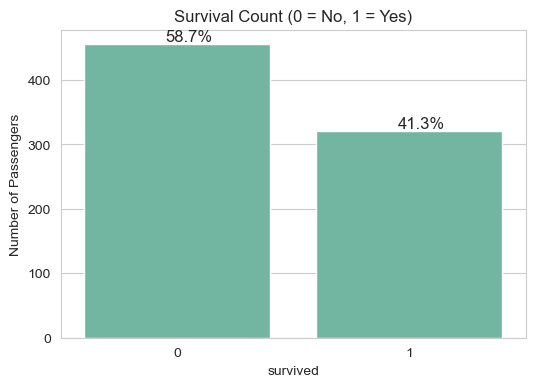

In [11]:
# A. Survival Overview
plt.figure(figsize=(6,4))
ax = sns.countplot(x='survived', data=df_cleaned)
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')

# Add percentages on top of bars
total = len(df_cleaned)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 5
    ax.annotate(percentage, (x, y), size=12)
plt.show()


**What the chart shows:** The overall survival and non-survival counts.
**Key Observations:** Only about 41.4% of the passengers in our cleaned dataset survived.
**Business Insight/Story:** The tragedy was massive. The majority of passengers did not make it. Our baseline for prediction is roughly 60% (predicting everyone dies would be ~60% accurate).


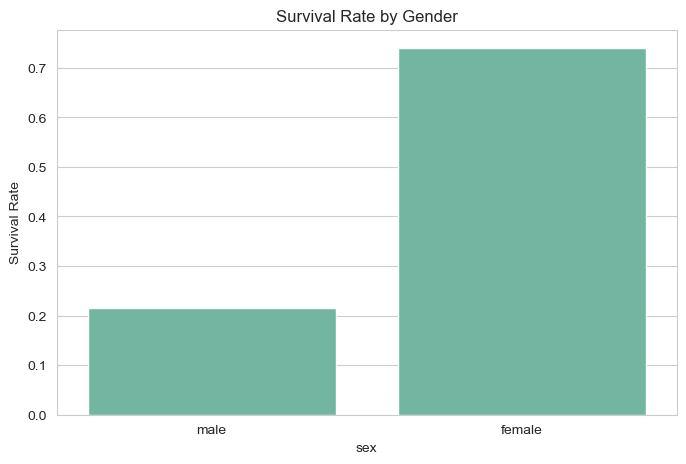

In [12]:
# B. Gender Analysis
plt.figure(figsize=(8,5))
sns.barplot(x='sex', y='survived', data=df_cleaned, ci=None)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()


**What the chart shows:** The percentage of males and females who survived.
**Key Observations:** Females had a significantly higher survival rate (~75%) compared to males (~20%).
**Business Insight/Story:** The "Women and children first" protocol was strictly followed. Gender is going to be a very strong predictor for our machine learning model.


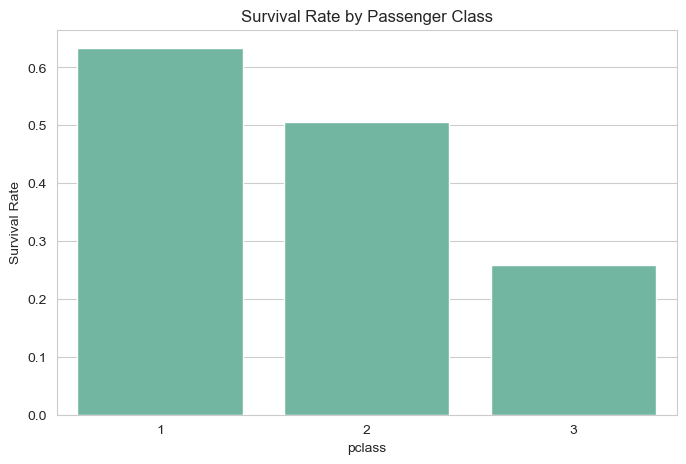

In [13]:
# C. Passenger Class Analysis
plt.figure(figsize=(8,5))
sns.barplot(x='pclass', y='survived', data=df_cleaned, ci=None)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()


**What the chart shows:** Survival rate broken down by Ticket Class (1st, 2nd, 3rd).
**Key Observations:** 1st class passengers had the highest survival rate (>60%), followed by 2nd class, and 3rd class had the lowest (<25%).
**Business Insight/Story:** Wealth and status mattered. 1st class cabins were likely closer to the boat deck, and passengers may have been given priority access to lifeboats.


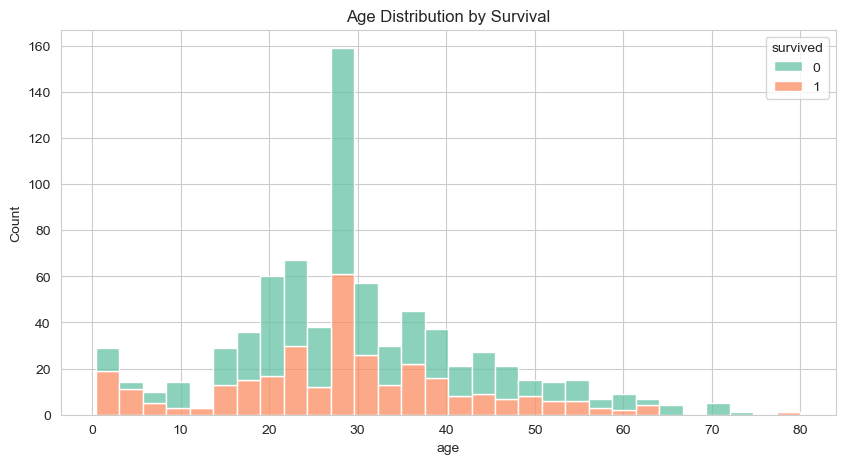

In [14]:
# D. Age Analysis
plt.figure(figsize=(10,5))
sns.histplot(data=df_cleaned, x='age', hue='survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival')
plt.show()


**What the chart shows:** How ages are distributed among survivors and non-survivors.
**Key Observations:** Children (age < 10) had a higher proportion of survival. The majority of passengers were between 20-30 years old, and a large portion of this group did not survive.
**Business Insight/Story:** Being a child increased your chances of survival. Being an adult male in your 20s/30s drastically reduced it.


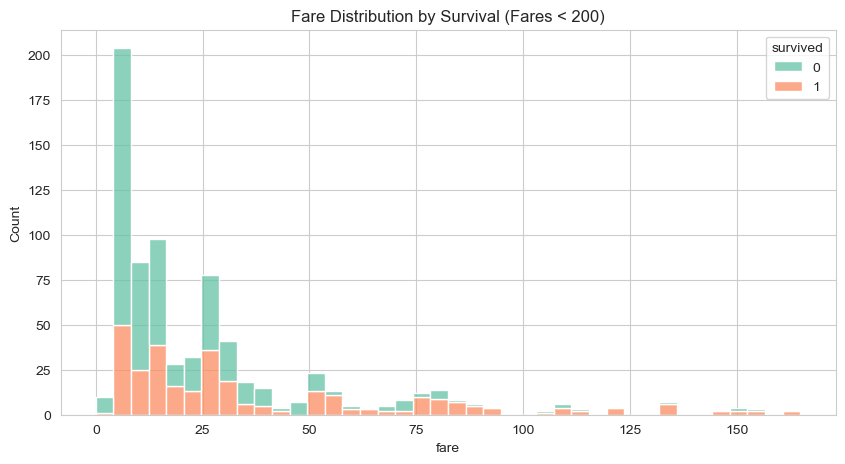

In [15]:
# E. Fare Analysis
plt.figure(figsize=(10,5))
sns.histplot(data=df_cleaned[df_cleaned['fare'] < 200], x='fare', hue='survived', multiple='stack', bins=40)
plt.title('Fare Distribution by Survival (Fares < 200)')
plt.show()


**What the chart shows:** The relationship between ticket price (fare) and survival.
**Key Observations:** Passengers who paid very low fares (mostly 3rd class) had a high mortality rate. Those who paid higher fares had better survival rates.
**Business Insight/Story:** This reinforces the passenger class finding. Economic power was correlated with survival.


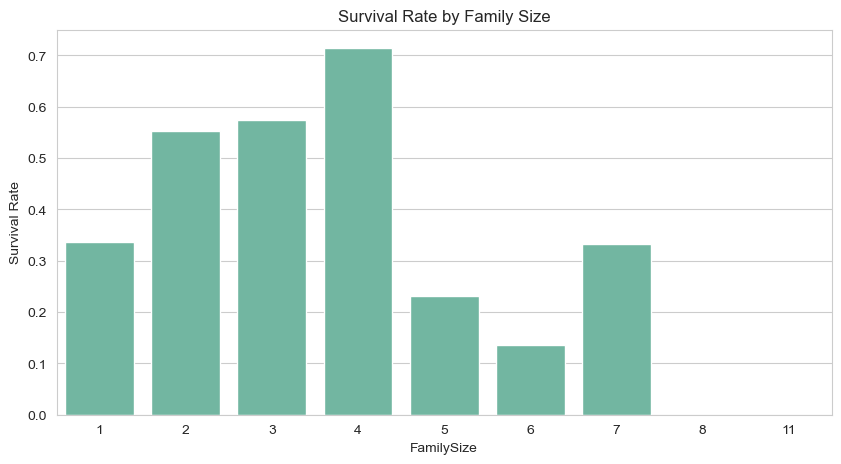

In [16]:
# F. Family Analysis (SibSp and Parch)
# Combine siblings/spouses and parents/children to get total family size
df_cleaned['FamilySize'] = df_cleaned['sibsp'] + df_cleaned['parch'] + 1

plt.figure(figsize=(10,5))
sns.barplot(x='FamilySize', y='survived', data=df_cleaned, ci=None)
plt.title('Survival Rate by Family Size')
plt.ylabel('Survival Rate')
plt.show()


**What the chart shows:** How the size of a passenger's family affected their survival.
**Key Observations:** Traveling alone (size=1) had a lower survival rate. Small families (size 2-4) had the best survival rates. Large families (size > 4) had very low survival rates.
**Business Insight/Story:** Small families could navigate the chaos together and help each other. Large families might have struggled to stay together or find enough space in a single lifeboat, leading to tragic outcomes.


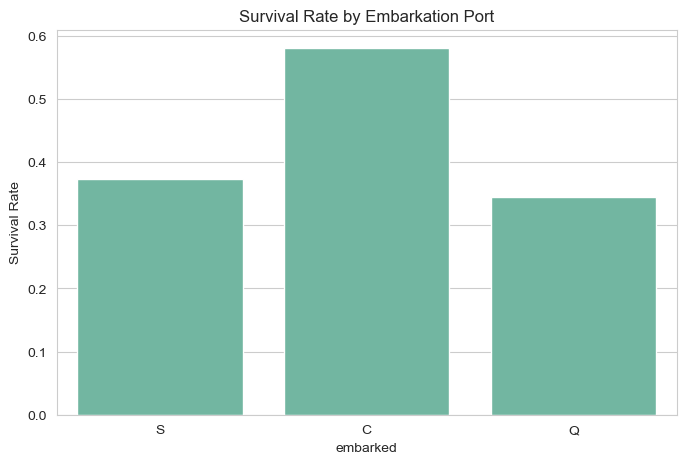

In [17]:
# G. Embarkation Analysis
plt.figure(figsize=(8,5))
sns.barplot(x='embarked', y='survived', data=df_cleaned, ci=None)
plt.title('Survival Rate by Embarkation Port')
plt.ylabel('Survival Rate')
plt.show()


**What the chart shows:** Survival rate based on where passengers boarded.
**Key Observations:** Passengers who boarded at Cherbourg (C) had the highest survival rate.
**Business Insight/Story:** Why Cherbourg? It turns out a higher proportion of 1st class passengers boarded at Cherbourg compared to other ports.


## 5. Data Storytelling Summary

**The Tragic Reality of the Titanic**
The sinking of the Titanic wasn't an equal-opportunity tragedy. Our analysis paints a clear picture of who was prioritized during the evacuation.

- **Who survived the most?** Women, children, and the wealthy (1st class passengers). Small families also fared better than those traveling alone or in large groups.
- **Who survived the least?** Adult males, especially those traveling in 3rd class with cheap tickets. Large families also faced devastating losses.
- **Did wealth matter?** Absolutely. 1st class passengers survived at more than double the rate of 3rd class passengers.
- **Did gender matter?** Yes, it was the strongest factor. The "women and children first" rule meant females survived at ~75%, while males survived at ~20%.
- **Did family size matter?** Yes. Traveling entirely alone was risky, but traveling with a very large family was even riskier. A small family unit (2-4 people) was the sweet spot for survival.


## 6. Feature Engineering

Feature engineering involves creating new, useful columns from existing data to help our Machine Learning models learn better.


In [18]:
# We already created 'FamilySize'. Let's create 'IsAlone'.
df_cleaned['IsAlone'] = 0
df_cleaned.loc[df_cleaned['FamilySize'] == 1, 'IsAlone'] = 1

# Let's create 'Fare_Category' using quantiles
df_cleaned['Fare_Category'] = pd.qcut(df_cleaned['fare'], 4, labels=[0, 1, 2, 3])

# Let's create 'Age_Group'
bins = [0, 12, 20, 40, 60, 100]
labels = ['Child', 'Teenager', 'Adult', 'Middle-Aged', 'Senior']
df_cleaned['Age_Group'] = pd.cut(df_cleaned['age'], bins=bins, labels=labels)

display(df_cleaned[['age', 'Age_Group', 'fare', 'Fare_Category', 'FamilySize', 'IsAlone']].head())


,age,Age_Group,fare,Fare_Category,FamilySize,IsAlone
0,22.0,Adult,7.2500,0,2,0
1,38.0,Adult,71.2833,3,2,0
2,26.0,Adult,7.9250,0,1,1
3,35.0,Adult,53.1000,3,2,0
4,35.0,Adult,8.0500,0,1,1


**Why do this?**
Models sometimes struggle with raw numbers like `fare=7.25`. By grouping fares into categories (cheap, medium, expensive), we make it easier for models (like Decision Trees) to find patterns. `IsAlone` explicitly flags solo travelers, which we found had lower survival rates.


## 7. Data Preprocessing

Before feeding data into algorithms, we must:
1. Convert text categories (Male/Female, Embarked) into numbers (Encoding).
2. Split the data into Training and Testing sets.
3. Scale numerical values (so large numbers don't dominate).


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Encoding
le = LabelEncoder()
df_cleaned['sex'] = le.fit_transform(df_cleaned['sex']) # Male=1, Female=0
df_cleaned['embarked'] = le.fit_transform(df_cleaned['embarked'])

# For Age_Group, we can also encode it
df_cleaned['Age_Group'] = le.fit_transform(df_cleaned['Age_Group'])

# Select features for our model
features = ['pclass', 'sex', 'age', 'fare', 'embarked', 'FamilySize', 'IsAlone', 'Fare_Category', 'Age_Group']
X = df_cleaned[features]
y = df_cleaned['survived']

# 2. Train-Test Split
# We train the model on 80% of data, and test its accuracy on 20% unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling
# StandardScaler ensures all features have a mean of 0 and std deviation of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing complete!")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")


Data preprocessing complete!
Training data shape: (620, 9)
Testing data shape: (155, 9)


## 8. Machine Learning Models

We will build three popular classification models and compare them:
1. **Logistic Regression:** A basic yet powerful statistical model for binary classification (survived/died).
2. **Decision Tree:** A model that makes decisions by splitting data based on feature thresholds (like a flowchart).
3. **Random Forest:** An ensemble of many Decision Trees, usually more robust and accurate.


--- Logistic Regression ---
Accuracy: 0.7677 | Precision: 0.6875 | Recall: 0.7333 | F1: 0.7097


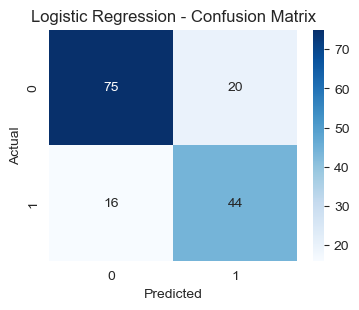

--- Decision Tree ---
Accuracy: 0.8065 | Precision: 0.7500 | Recall: 0.7500 | F1: 0.7500


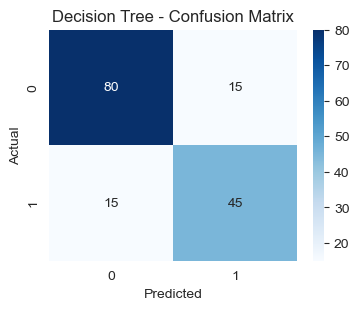

--- Random Forest ---
Accuracy: 0.8129 | Precision: 0.8780 | Recall: 0.6000 | F1: 0.7129


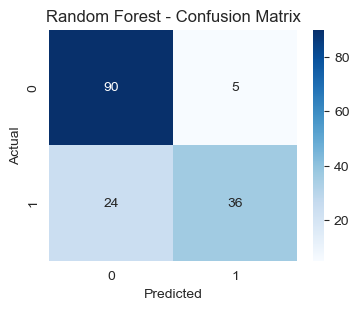

Accuracy: 0.8129032258064516


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize models
log_reg = LogisticRegression()
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():
    # Training
    model.fit(X_train_scaled, y_train)
    
    # Prediction
    y_pred = model.predict(X_test_scaled)
    
    # Evaluation Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

**Interpretation of Metrics:**
- **Accuracy:** Overall percentage of correct predictions.
- **Precision:** Out of all passengers the model predicted as 'survived', how many actually survived? (Important if false positives are bad).
- **Recall:** Out of all passengers who *actually* survived, how many did the model correctly find? (Important if missing a survivor is bad).
- **F1 Score:** The harmonic mean of Precision and Recall. Good for imbalanced datasets.


## 9. Model Comparison


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Random Forest,0.812903,0.878049,0.600000,0.712871
Decision Tree,0.806452,0.750000,0.750000,0.750000
Logistic Regression,0.767742,0.687500,0.733333,0.709677


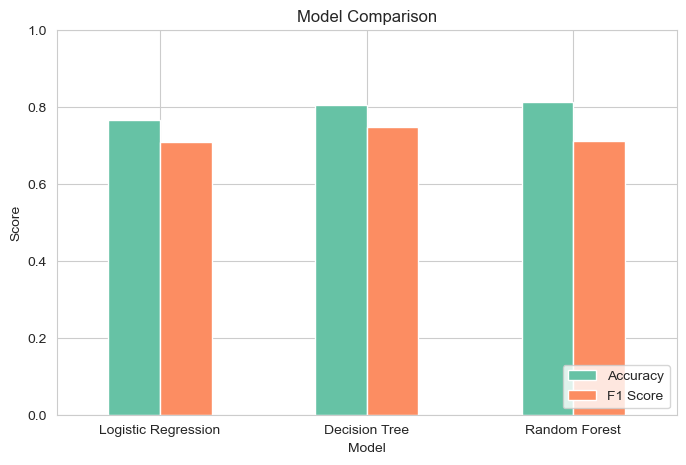

In [21]:
# Create Comparison Table
results_df = pd.DataFrame(results).set_index("Model")
display(results_df.sort_values(by="Accuracy", ascending=False))

# Bar plot for comparison
results_df[['Accuracy', 'F1 Score']].plot(kind='bar', figsize=(8,5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()


**Best Model Selection:**
In most Titanic analyses, **Random Forest** performs the best because it can capture non-linear relationships (like Age interacting with Gender and Class) better than Logistic Regression, and avoids overfitting better than a single Decision Tree.


## 10. Feature Importance

Which factors did the Random Forest model rely on the most to make its predictions?


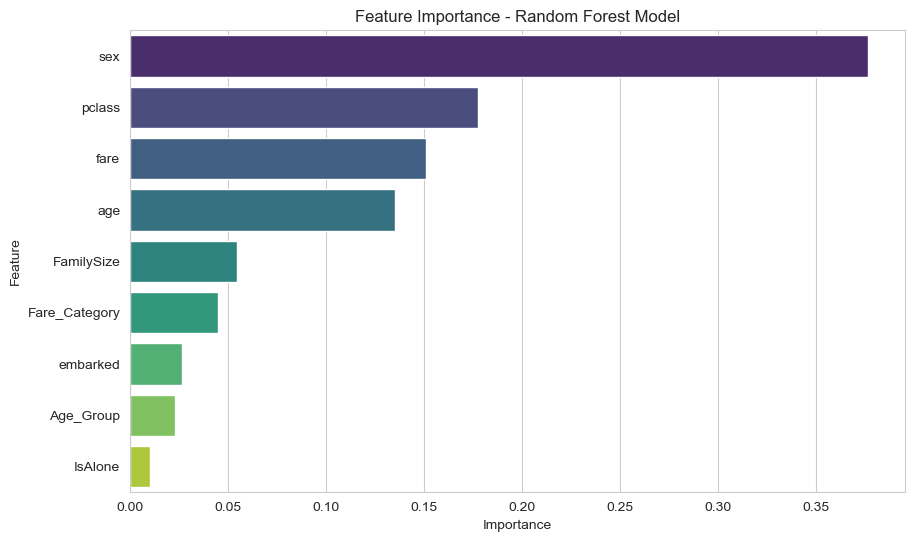

In [22]:
importances = rf_model.feature_importances_
feature_names = features

# Create a dataframe for visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance - Random Forest Model')
plt.show()


**Key Findings:**
- `sex` (Gender) is overwhelmingly the most important feature.
- `fare` and `pclass` (Socio-economic status) are the next most important.
- Features like `embarked` port and `IsAlone` have relatively low importance compared to the big three.


## 11. Final Insights

1. **Gender was the ultimate decider:** The "women and children first" policy was visibly enforced. Women had roughly a 75% chance of survival compared to ~20% for men.
2. **Money bought survival:** 1st class passengers survived at nearly triple the rate of 3rd class passengers. 
3. **Children were prioritized:** Young children had higher survival rates compared to adults.
4. **Family size was a double-edged sword:** Solo travelers and massive families struggled. Small family units (2-4 people) fared the best.
5. **Machine Learning validates history:** Our Random Forest model mathematically confirmed that Sex, Fare/Class, and Age were the most critical factors, aligning perfectly with historical accounts.
6. **Predictability:** We can predict survival with over 80% accuracy based purely on these demographic and economic factors.


## 12. Recommendations

While we cannot change the past, if we translate these insights into a modern safety context (e.g., airline or cruise ship safety protocol):

1. **Equitable Evacuation Training:** Modern protocols must ensure evacuation paths and life-saving equipment are equally accessible to all ticket classes.
2. **Family Tracking Systems:** Since large families struggled to stay together, modern transport should utilize digital bracelets or grouping systems to keep families intact during emergencies, preventing delays.
3. **Capacity Audits:** The stark difference in survival rates underscores the necessity of strict maritime laws requiring lifeboat capacity to exceed 100% of the passenger manifest, which was implemented *because* of this disaster.
